In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
import os
import numpy as np

### Bikes dataset

In [35]:
bikes_df = pd.read_csv("./bikes/hour.csv")
bikes_df

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


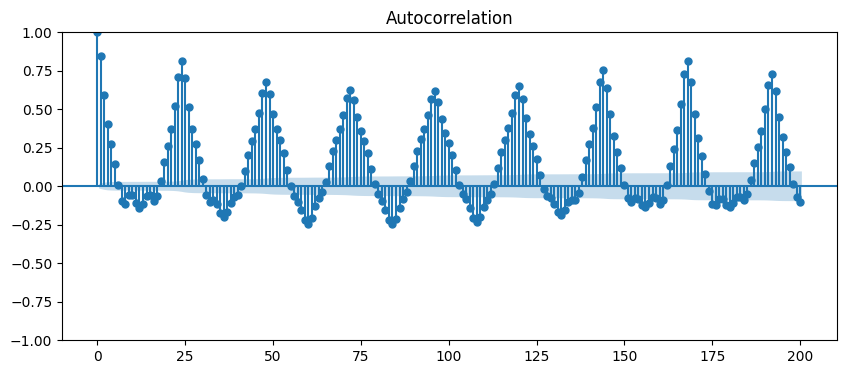

In [75]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(bikes_df['cnt'].dropna(), lags=200, ax=ax)
plt.show()

Daily demand correlation suggests that what happens right now depends on yesterday this time.

Stays strongly correlated for large lags. Also 168hr (week) strong correlation.

Seasonal/cyclical non-stationarity

In [36]:
from statsmodels.tsa.stattools import adfuller

def run_adf(series, label):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'{label}')
    print(f'  ADF statistic: {result[0]:.4f}')
    print(f'  p-value:       {result[1]:.4f}')
    print(f'  # lags used:   {result[2]}')
    print(f'  # obs used:    {result[3]}')
    for pct, crit in result[4].items():
        print(f'  critical value ({pct}): {crit:.4f}')
    truth = True if result[1] < 0.05 else False
    print(f'  Stationary at 5%? {truth}')
    print()
    return result

run_adf(bikes_df['cnt'], 'Raw cnt')

Raw cnt
  ADF statistic: -6.8229
  p-value:       0.0000
  # lags used:   42
  # obs used:    17336
  critical value (1%): -3.4307
  critical value (5%): -2.8617
  critical value (10%): -2.5669
  Stationary at 5%? True



(np.float64(-6.822918711895086),
 np.float64(1.980862627797932e-09),
 42,
 17336,
 {'1%': np.float64(-3.430727265144117),
  '5%': np.float64(-2.8617067365231246),
  '10%': np.float64(-2.5668587495404225)},
 np.float64(191103.95056018294))

In [37]:
BIKES_MEAN = np.mean(bikes_df["cnt"])
print(BIKES_MEAN)

189.46308763450142


One observation per recorded hour. Combined `dteday` and `hr` to obtain the
timestamp. 

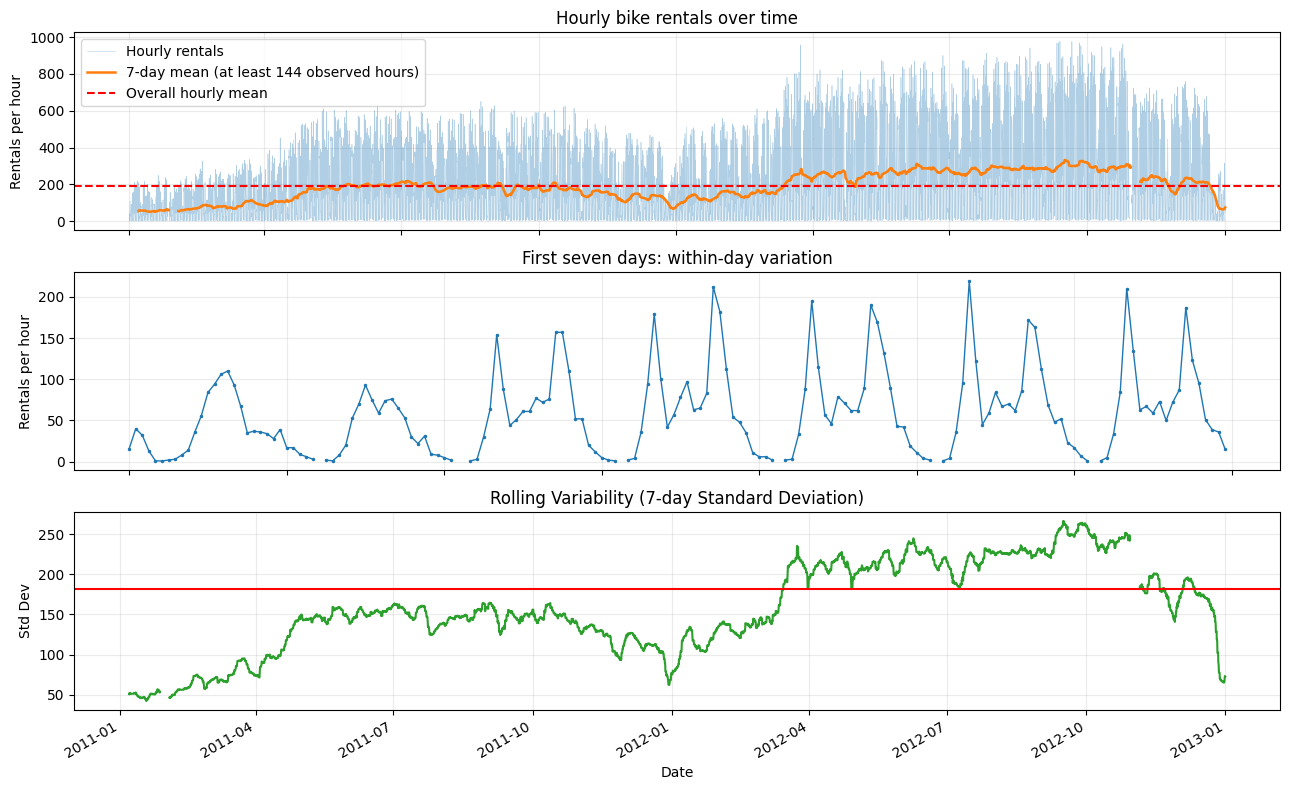

In [38]:
bikes_df['date'] = (pd.to_datetime(bikes_df['dteday'])
                    + pd.to_timedelta(bikes_df['hr'], unit='h'))
df1 = bikes_df.sort_values('date').copy()
assert df1['date'].is_unique, 'Resolve duplicate hourly timestamps.'
hourly_counts = df1.set_index('date')['cnt'].asfreq('h')
fig, axes = plt.subplots(3, 1, figsize=(13, 8))
axes[0].plot(hourly_counts.index, hourly_counts, linewidth=0.4,
             alpha=0.35, label='Hourly rentals')
axes[0].plot(hourly_counts.rolling('7D', min_periods=144).mean(),
             color='tab:orange', linewidth=1.8, label='7-day mean (at least 144 observed hours)')
axes[0].axhline(hourly_counts.mean(), color='red', linestyle='--', label='Overall hourly mean')
axes[0].set(title='Hourly bike rentals over time', xlabel='Date', ylabel='Rentals per hour')

week_start = hourly_counts.index.min()
week = hourly_counts.loc[(hourly_counts.index >= week_start)
                         & (hourly_counts.index < week_start + pd.Timedelta(days=7))]
axes[1].plot(week.index, week, linewidth=1, marker='.', markersize=3)
axes[1].set(title='First seven days: within-day variation', xlabel='Timestamp', ylabel='Rentals per hour')

rolling_std = hourly_counts.rolling('7D', min_periods=144).std()

axes[2].plot(rolling_std.index, rolling_std, color='tab:green', label='7-day rolling standard deviation')
axes[2].axhline(hourly_counts.std(), color='red', label='Overall standard deviation')
axes[2].set(title='Rolling Variability (7-day Standard Deviation)', xlabel='Date', ylabel='Std Dev')

for ax in axes:
    ax.grid(alpha=0.25)
axes[0].legend()
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

Looks like hour-of-day might be a useful metric for signal to demand

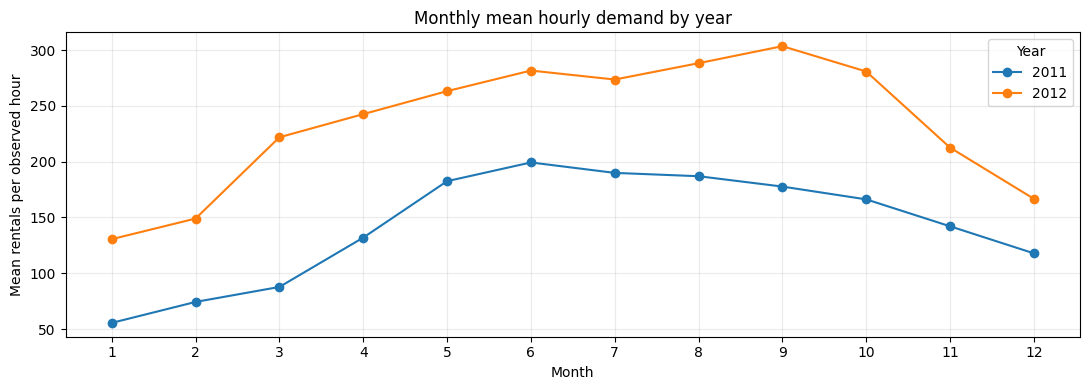

In [39]:
monthly_means = df1.groupby([df1['date'].dt.year, 'mnth'])['cnt'].mean().unstack(0)
ax = monthly_means.plot(marker='o', figsize=(11, 4))
ax.set(title='Monthly mean hourly demand by year', xlabel='Month',
       ylabel='Mean rentals per observed hour', xticks=range(1, 13))
ax.legend(title='Year')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Over the two years, there is clearly a `seasonal` trend. Since the data is from Washington, USA, summer season (mid-year) tends to record higher bike counts.

## Exploratory analysis of hourly bike counts

`casual` and `registered` are excluded from predictor plots because their sum is `cnt`

using their target-hour values would leak the target

In [40]:
import numpy as np
from IPython.display import display

eda = df1.set_index('date').copy()
eda['year'] = eda.index.year
eda['quarter'] = eda.index.to_period('Q').astype(str)
print(f'{len(eda):,} recorded hours; {hourly_counts.isna().sum():,} missing hours '
      'between the first and last timestamp.')
display(eda.groupby('year')['cnt'].agg(['count', 'mean', 'std', 'min', 'max']).round(1))

17,379 recorded hours; 165 missing hours between the first and last timestamp.


,count,mean,std,min,max
year,,,,,
2011,8645,143.8,133.8,1,651
2012,8734,234.7,208.9,1,977


Not every chornoligical timestamp is present. Will have to consider perhaps splitting sequences here. Cannot expect to train model on fixed sequence single timesteps and predict a gap/jump

Also, clearly second year more demand

### Hour-of-day and weekday patterns


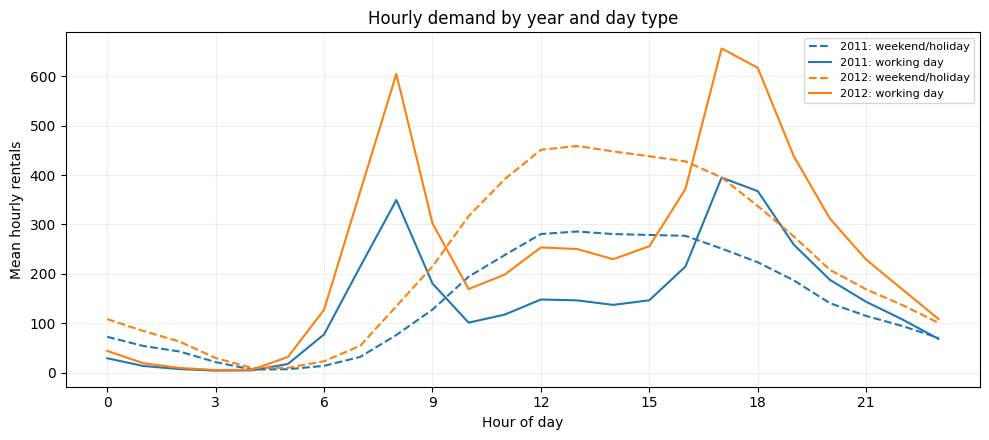

In [41]:
fig, ax = plt.subplots(figsize=(10, 4.5))

for (year, workingday), group in eda.groupby(["year", "workingday"]):
  profile = group.groupby("hr")["cnt"].mean().reindex(range(24))
  day_type = "working day" if workingday else "weekend/holiday"

  ax.plot(
      profile.index,
      profile,
      label=f"{year}: {day_type}",
      linestyle="-" if workingday else "--",
      color="tab:blue" if year == 2011 else "tab:orange",
  )

ax.set(
    title="Hourly demand by year and day type",
    xlabel="Hour of day",
    ylabel="Mean hourly rentals",
    xticks=range(0, 24, 3),
)
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

fig.tight_layout()
plt.show()

Seems to be more popularity in year 2 -> non-stationarity

In weekdays clear morning and evening demand high

Weekends/holiday peak midday

### Continuous features and the target



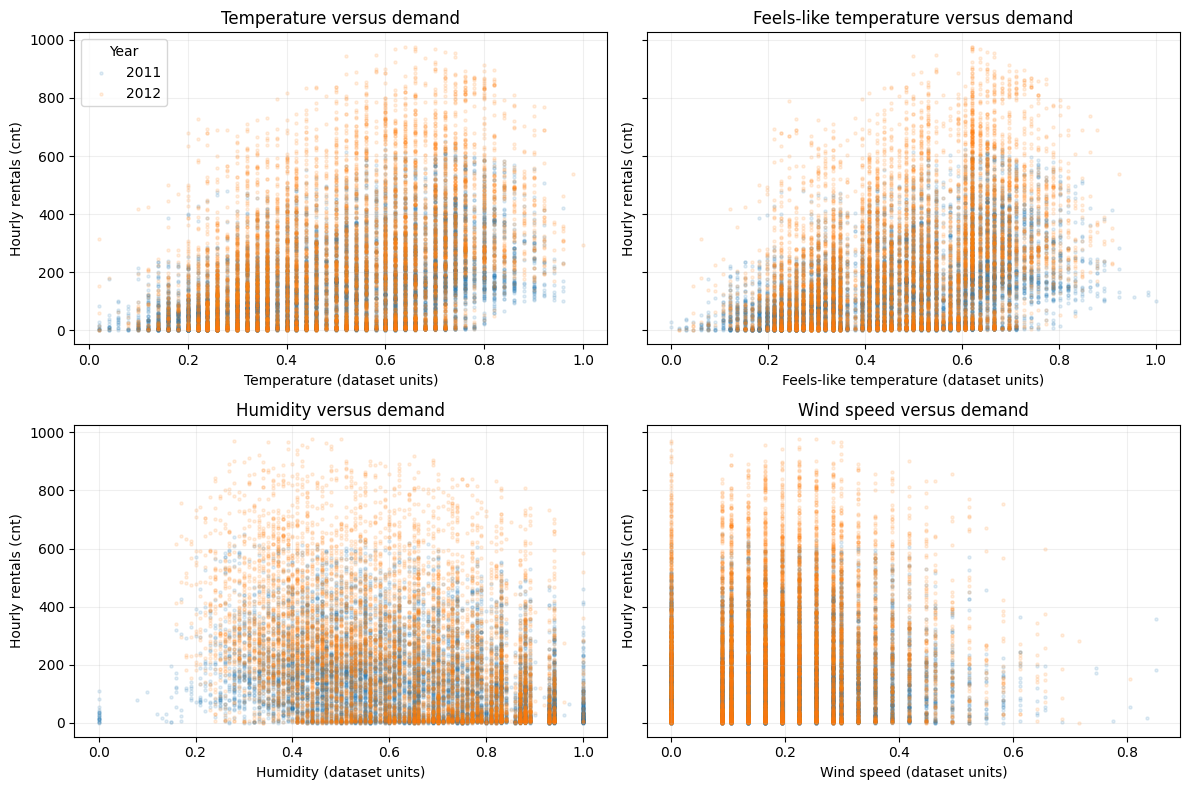

In [42]:
features = {'temp': 'Temperature', 'atemp': 'Feels-like temperature',
            'hum': 'Humidity', 'windspeed': 'Wind speed'}
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
for ax, (feature, label) in zip(axes.flat, features.items()):
    for year, group in eda.groupby('year'):
        ax.scatter(group[feature], group['cnt'], s=5, alpha=0.12, rasterized=True, label=str(year))
    ax.set(xlabel=f'{label} (dataset units)', ylabel='Hourly rentals (cnt)',
           title=f'{label} versus demand')
    ax.grid(alpha=0.2)
axes[0, 0].legend(title='Year')
fig.tight_layout()
plt.show()

Drop humidity little relation visible

In [43]:
#bikes_df = bikes_df.drop(columns=["hum"])

In [44]:
bikes_df[["temp", "atemp"]].corr()

,temp,atemp
temp,1.000000,0.987672
atemp,0.987672,1.000000


In [45]:
# Check correlation of temp and atemp with the target 'cnt'
target_corr = bikes_df[['temp', 'atemp', 'cnt']].corr()['cnt']
print(target_corr)

temp     0.404772
atemp    0.400929
cnt      1.000000
Name: cnt, dtype: float64


Near duplicates

In [46]:
bikes_df = bikes_df.drop(columns=['temp'])
bikes_df

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,atemp,hum,windspeed,casual,registered,cnt,date
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.2879,0.81,0.0000,3,13,16,2011-01-01 00:00:00
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.2727,0.80,0.0000,8,32,40,2011-01-01 01:00:00
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.2727,0.80,0.0000,5,27,32,2011-01-01 02:00:00
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.2879,0.75,0.0000,3,10,13,2011-01-01 03:00:00
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.2879,0.75,0.0000,0,1,1,2011-01-01 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.2576,0.60,0.1642,11,108,119,2012-12-31 19:00:00
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.2576,0.60,0.1642,8,81,89,2012-12-31 20:00:00
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.2576,0.60,0.1642,7,83,90,2012-12-31 21:00:00
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.2727,0.56,0.1343,13,48,61,2012-12-31 22:00:00


In [47]:
bikes_df = bikes_df.drop(columns=["casual", "registered"])
bikes_df

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,atemp,hum,windspeed,cnt,date
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.2879,0.81,0.0000,16,2011-01-01 00:00:00
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.2727,0.80,0.0000,40,2011-01-01 01:00:00
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.2727,0.80,0.0000,32,2011-01-01 02:00:00
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.2879,0.75,0.0000,13,2011-01-01 03:00:00
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.2879,0.75,0.0000,1,2011-01-01 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.2576,0.60,0.1642,119,2012-12-31 19:00:00
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.2576,0.60,0.1642,89,2012-12-31 20:00:00
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.2576,0.60,0.1642,90,2012-12-31 21:00:00
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.2727,0.56,0.1343,61,2012-12-31 22:00:00


The scatter plots show marginal associations at hourly rates. 

Seems like positive relation between temp and demand. But not stationary -> changes for different year

### Distribution changes through time


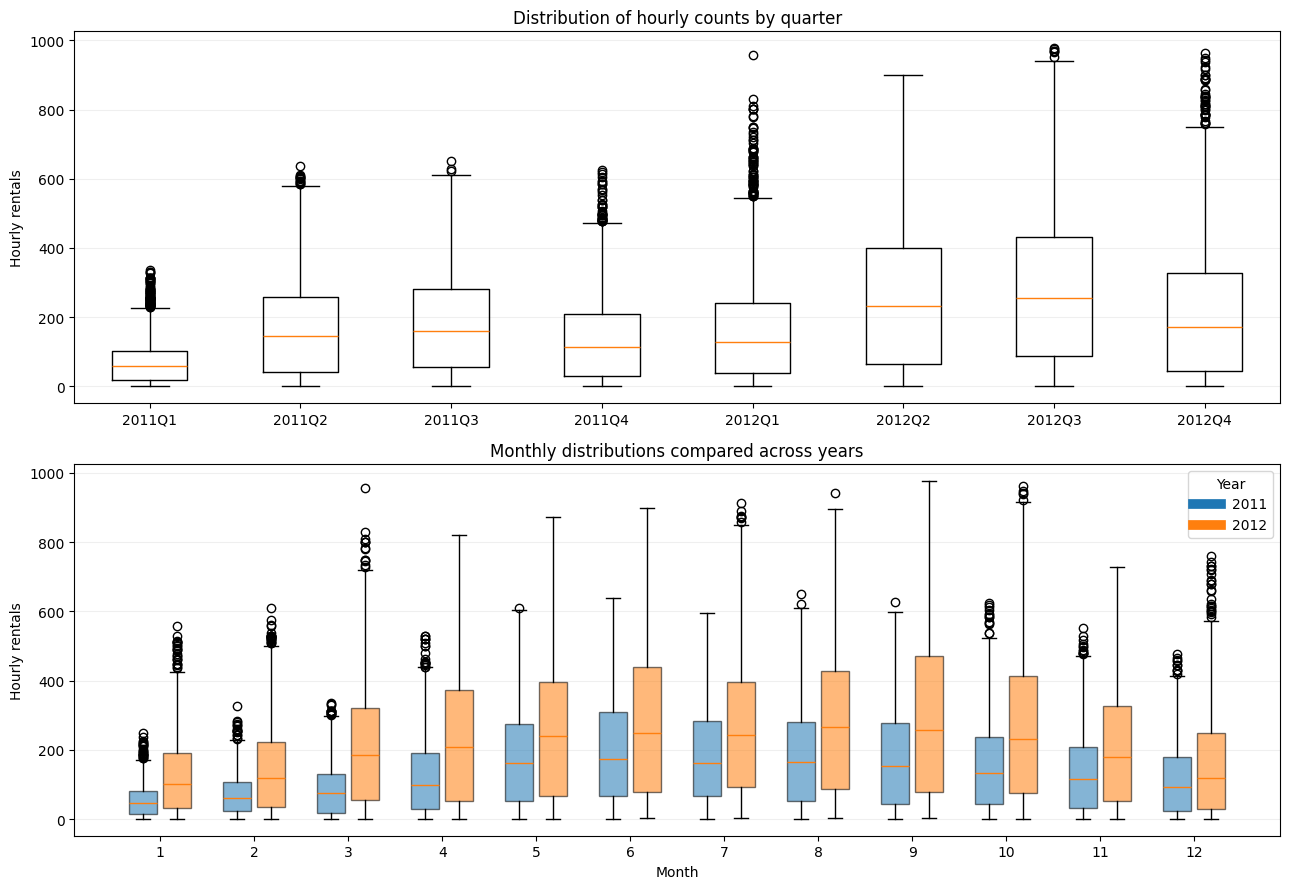

In [48]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9))
quarters = sorted(eda['quarter'].unique())
axes[0].boxplot([eda.loc[eda['quarter'].eq(q), 'cnt'] for q in quarters])
axes[0].set_xticks(range(1, len(quarters) + 1), quarters)
axes[0].set(title='Distribution of hourly counts by quarter', ylabel='Hourly rentals')
for year, offset, color in [(2011, -0.18, 'tab:blue'), (2012, 0.18, 'tab:orange')]:
    groups = [eda.loc[eda['year'].eq(year) & eda['mnth'].eq(m), 'cnt'] for m in range(1, 13)]
    boxes = axes[1].boxplot(groups, positions=np.arange(1, 13) + offset,
                            widths=0.30, patch_artist=True, manage_ticks=False)
    for box in boxes['boxes']:
        box.set(facecolor=color, alpha=0.55)
    axes[1].plot([], [], color=color, linewidth=7, label=str(year))
axes[1].set(xticks=range(1, 13), xlabel='Month', ylabel='Hourly rentals',
            title='Monthly distributions compared across years')
axes[1].legend(title='Year')
for ax in axes:
    ax.grid(axis='y', alpha=0.2)
fig.tight_layout()
plt.show()

### Is the raw hourly series stationary?
Stationarity requires a constant mean and variance.

The 30-day rolling mean and standard deviation below smooth the within-day and
within-week cycles.

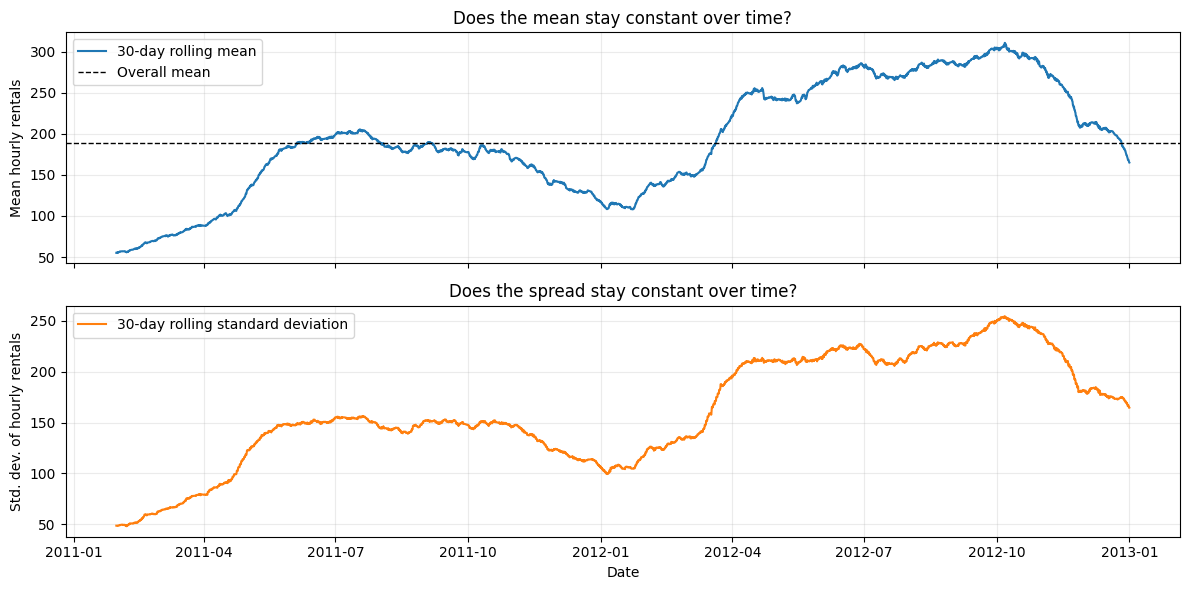

,Mean hourly rentals,Std. dev. of hourly rentals
year,,
2011,143.8,133.8
2012,234.7,208.9


In [49]:
rolling_counts = hourly_counts.rolling('30D', min_periods=648)
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(rolling_counts.mean(), color='tab:blue', label='30-day rolling mean')
axes[0].axhline(hourly_counts.mean(), color='black', linestyle='--',
                linewidth=1, label='Overall mean')
axes[0].set(title='Does the mean stay constant over time?', ylabel='Mean hourly rentals')
axes[1].plot(rolling_counts.std(), color='tab:orange', label='30-day rolling standard deviation')
axes[1].set(title='Does the spread stay constant over time?',
            ylabel='Std. dev. of hourly rentals', xlabel='Date')
for ax in axes:
    ax.legend(loc='upper left')
    ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

year_summary = eda.groupby('year')['cnt'].agg(['mean', 'std']).round(1)
display(year_summary.rename(columns={'mean': 'Mean hourly rentals',
                                     'std': 'Std. dev. of hourly rentals'}))
matched_months = eda.groupby(['mnth', 'year'])['cnt'].mean().unstack('year')


### Hourly differences
Change from the previous hour: `cnt(t) - cnt(t-1)`

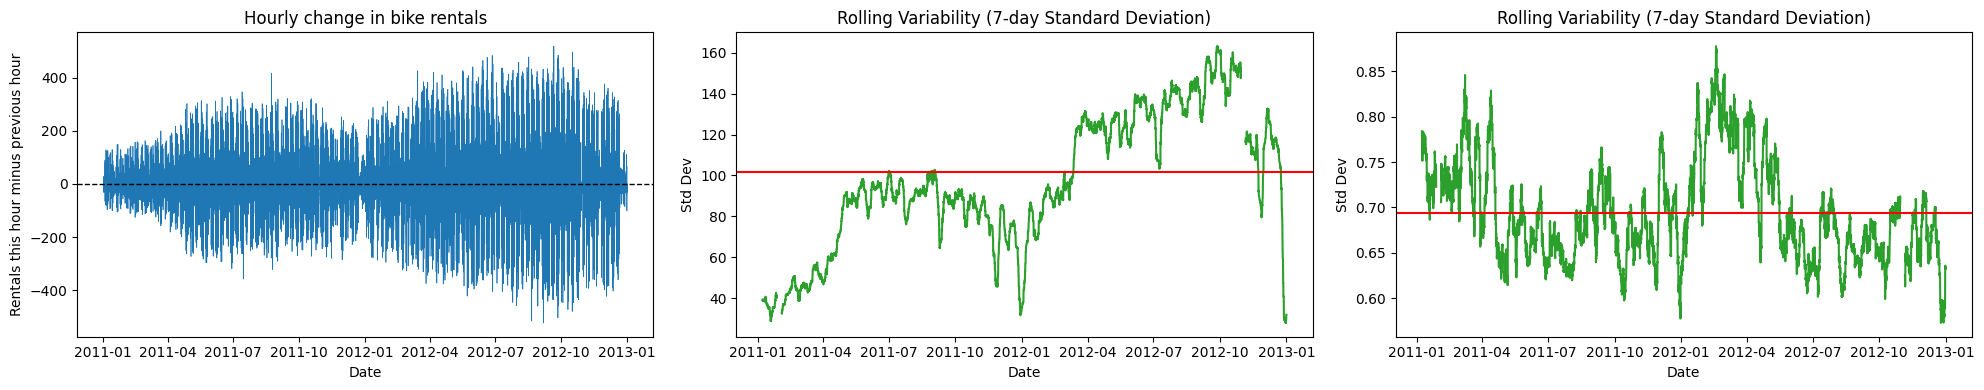

In [50]:
hourly_difference = hourly_counts.diff()
fig, axes = plt.subplots(1,3,figsize=(20, 4))
axes[0].plot(hourly_difference.index, hourly_difference, linewidth=0.5, color='tab:blue')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set(title='Hourly change in bike rentals', xlabel='Date',
       ylabel='Rentals this hour minus previous hour')

rolling_std2 = hourly_difference.rolling('7D', min_periods=144).std()

axes[1].plot(rolling_std2.index, rolling_std2, color='tab:green', label='7-day rolling standard deviation')
axes[1].axhline(hourly_difference.std(), color='red', label='Overall standard deviation')
axes[1].set(title='Rolling Variability (7-day Standard Deviation)', xlabel='Date', ylabel='Std Dev')


log_diff = np.log(hourly_counts).diff()
rolling_std3 = log_diff.rolling('7D', min_periods=144).std()
axes[2].plot(rolling_std3.index, rolling_std3, color='tab:green', label='7-day rolling standard deviation')
axes[2].axhline(log_diff.std(), color='red', label='Overall standard deviation')
axes[2].set(title='Rolling Variability (7-day Standard Deviation)', xlabel='Date', ylabel='Std Dev')


ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

In [51]:
hourly_counts

date
2011-01-01 00:00:00     16.0
2011-01-01 01:00:00     40.0
2011-01-01 02:00:00     32.0
2011-01-01 03:00:00     13.0
2011-01-01 04:00:00      1.0
                       ...  
2012-12-31 19:00:00    119.0
2012-12-31 20:00:00     89.0
2012-12-31 21:00:00     90.0
2012-12-31 22:00:00     61.0
2012-12-31 23:00:00     49.0
Freq: h, Name: cnt, Length: 17544, dtype: float64

More fixed in time/stationary hourly demand differences -> possibility for predicting difference at time t and add to cnt(t-1) to get prediction. This will enable us to train on non-temporally changing data

Variables to consider:

`hr`, `weekday`. (`mnth` or `season` - one, carry similar information) to encode cyclically

`workingday`, `holiday`

`temp`, `hum`, `windspeed`

`cnt` t-1

`yr` if training and pred includes both years so no extrapolation

but no generliasaiton to future years so maybe rather not
perhaps use differencing becuase relation seems constant in time in difference

cyclical feautres dont break down in extrapolation. never encounter exptrapolation 

also inlcuding season but not yr means model doesnt capture effects of year temporal dependency/non stationarity however just use differencing

In [52]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from IPython.display import display

bikes = pd.read_csv('./bikes/hour.csv')
bikes['date'] = pd.to_datetime(bikes['dteday']) + pd.to_timedelta(bikes['hr'], unit='h')
bikes = bikes.set_index('date').sort_index()
assert bikes.index.is_unique
bikes = bikes.asfreq('h')

features = bikes[['cnt', 'temp', 'windspeed']].copy()
# Lags are relative to each input row; windows end one hour before the target.
# asfreq('h') above makes this 24 elapsed hours, even across missing records.
features['lag_cnt_24hr'] = bikes['cnt'].shift(24)
features['missing'] = features.isna().any(axis=1).astype(float)
for name, phase in {
    'hour': bikes.index.hour / 24,
    'weekday': bikes.index.dayofweek / 7,
    'year': (bikes.index.dayofyear - 1) / np.where(bikes.index.is_leap_year, 366, 365)
}.items():
    features[name + '_sin'] = np.sin(2 * np.pi * phase)
    features[name + '_cos'] = np.cos(2 * np.pi * phase)

target_change = bikes['cnt'].diff()
print(f'{len(bikes):,} hourly slots; {bikes["cnt"].isna().sum()} missing counts.')
print('Input features:', features.columns.tolist())


17,544 hourly slots; 165 missing counts.
Input features: ['cnt', 'temp', 'windspeed', 'lag_cnt_24hr', 'missing', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'year_sin', 'year_cos']


Cyclical features like weekday and hours and day of year were cosine/sine pair transformed to capture cyclical adjacencies

log(cnt(t+1))-log(cnt(t)) = log(cnt(t+1)/cnt(t))

Create volatility here, after the hourly grid and `missing` marker exist but before `prepare_bike_block` scales the features. The change is kept only when both counts are observed. `shift(1)` makes the feature causal: volatility on row `t` cannot use the change ending at `t`. Rolling features and scalers are therefore based only on information available before the row being represented.

even when building data for a length=1 model a timestamp t is only accepted into valid if the entire 168-hour window behind it is fully finite

In [53]:
log_count = np.log(bikes['cnt'])
observed_count = bikes['cnt'].notna()
observed_transition = observed_count & observed_count.shift(1, fill_value=False)

target_change_log = log_count.diff().where(observed_transition)

past_log_change = target_change_log.shift(1)
features['volatility_168h'] = past_log_change.rolling(
    window=168, min_periods=6
).std()

print('Input features after adding volatility:', features.columns.tolist())
features[['cnt', 'missing', 'volatility_168h']].head(30)

Input features after adding volatility: ['cnt', 'temp', 'windspeed', 'lag_cnt_24hr', 'missing', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'year_sin', 'year_cos', 'volatility_168h']


,cnt,missing,volatility_168h
date,,,
2011-01-01 00:00:00,16.0,1.0,NaN
2011-01-01 01:00:00,40.0,1.0,NaN
2011-01-01 02:00:00,32.0,1.0,NaN
2011-01-01 03:00:00,13.0,1.0,NaN
2011-01-01 04:00:00,1.0,1.0,NaN
2011-01-01 05:00:00,1.0,1.0,NaN
2011-01-01 06:00:00,2.0,1.0,NaN
2011-01-01 07:00:00,3.0,1.0,1.268033
2011-01-01 08:00:00,8.0,1.0,1.191939


In [54]:
features

,cnt,temp,windspeed,lag_cnt_24hr,missing,hour_sin,hour_cos,weekday_sin,weekday_cos,year_sin,year_cos,volatility_168h
date,,,,,,,,,,,,
2011-01-01 00:00:00,16.0,0.24,0.0000,NaN,1.0,0.000000,1.000000,-0.974928,-0.222521,0.000000,1.000000,NaN
2011-01-01 01:00:00,40.0,0.22,0.0000,NaN,1.0,0.258819,0.965926,-0.974928,-0.222521,0.000000,1.000000,NaN
2011-01-01 02:00:00,32.0,0.22,0.0000,NaN,1.0,0.500000,0.866025,-0.974928,-0.222521,0.000000,1.000000,NaN
2011-01-01 03:00:00,13.0,0.24,0.0000,NaN,1.0,0.707107,0.707107,-0.974928,-0.222521,0.000000,1.000000,NaN
2011-01-01 04:00:00,1.0,0.24,0.0000,NaN,1.0,0.866025,0.500000,-0.974928,-0.222521,0.000000,1.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-31 19:00:00,119.0,0.26,0.1642,102.0,0.0,-0.965926,0.258819,0.000000,1.000000,-0.017166,0.999853,0.633994
2012-12-31 20:00:00,89.0,0.26,0.1642,72.0,0.0,-0.866025,0.500000,0.000000,1.000000,-0.017166,0.999853,0.633278
2012-12-31 21:00:00,90.0,0.26,0.1642,47.0,0.0,-0.707107,0.707107,0.000000,1.000000,-0.017166,0.999853,0.633504


### Five separate chronological blocks

Reserve October–December 2012 for the final test. Divided the earlier data into five **non-overlapping blocks**. Within each block:

- First 68%: fit the model and scalers.
- Next 12%: early stopping.
- Final 20%: testing on retrained 80%

In [55]:
sequence_lengths = [1,2 ,3, 6, 12, 24, 48, 168] # one day two days, and one week lags
test_start = bikes.index.get_loc('2012-10-01 00:00:00')

blocks = []
for positions in np.array_split(np.arange(test_start), 5):
    start, end = int(positions[0]), int(positions[-1] + 1)
    train_end = start + int(0.8 * (end - start))
    blocks.append((start, train_end, end))

display(pd.DataFrame([
    {'fold': i + 1, 'block_start': bikes.index[start],
     'early_stop_start': bikes.index[start + int(0.85 * (train_end - start))],
     'validation_start': bikes.index[train_end], 'block_end': bikes.index[end - 1]}
    for i, (start, train_end, end) in enumerate(blocks)
]))


,fold,block_start,early_stop_start,validation_start,block_end
0,1,2011-01-01 00:00:00,2011-03-28 21:00:00,2011-04-13 06:00:00,2011-05-08 19:00:00
1,2,2011-05-08 20:00:00,2011-08-03 17:00:00,2011-08-19 01:00:00,2011-09-13 14:00:00
2,3,2011-09-13 15:00:00,2011-12-09 12:00:00,2011-12-24 20:00:00,2012-01-19 09:00:00
3,4,2012-01-19 10:00:00,2012-04-15 07:00:00,2012-04-30 15:00:00,2012-05-26 04:00:00
4,5,2012-05-26 05:00:00,2012-08-21 02:00:00,2012-09-05 10:00:00,2012-09-30 23:00:00


[block_start; validation_start-1] is effectively training data

no shuffling -> preserve sequential meaning

Convert to date-time index so as to obtain folds by date indexing

Will not use date for training variable since may extrapolate
Blocked-time-series splits ensures space between validation and training so that no lag leakage/overlap into training 

## Pre-processing
### Scale and create sequences inside each block

The short model might look better or worse simply because it was tested on a completely different set of time points than the long model. This is why we when finding valid samples consider the maximum sequence length everytime so training looks as similar as possible

In [ ]:
def prepare_bike_block(start, train_end, end, length):
    assert length in sequence_lengths
    fit_end = int(0.85 * (train_end - start))
    validation_start = train_end - start

    x = features.iloc[start:end].ffill(limit=3).to_numpy()
    y = target_change_log.iloc[start:end].to_numpy()
    counts = bikes['cnt'].iloc[start:end].to_numpy()

    longest = max(sequence_lengths)
    valid = np.array([
        t for t in range(longest, len(x))
        if np.isfinite(x[t-longest:t]).all() and np.isfinite(y[t])
    ], dtype=int)
    groups = {
        'train': valid[valid < fit_end],
        'stop': valid[(valid >= fit_end) & (valid < validation_start)],
        'validation': valid[valid >= validation_start]
    }
    assert all(len(ids) for ids in groups.values()), 'A split has no usable sequences.'

    x_scaler = StandardScaler().fit(x[:fit_end][np.isfinite(x[:fit_end]).all(axis=1)])
    y_scaler = StandardScaler().fit(y[groups['train'], None])
    x_scaled = x_scaler.transform(x)
    prepared = {}
    for name, ids in groups.items():
        prepared[name] = {
            'X': np.stack([x_scaled[t-length:t] for t in ids]).astype('float32'),
            'y': y_scaler.transform(y[ids, None]).astype('float32'),
            'last_count': counts[ids - 1],
            'actual': counts[ids],
            'dates': bikes.index[start + ids]
        }
    return prepared, x_scaler, y_scaler


### How I decide on valid/sequences to keep
consider the lookback period of a sequence

ids contains only the valid indices that fall within the first 85% of the training window. When it runs for validation, ids contains only the valid indices from the held-out test block.

NB equences containing those short three step forward-filled values are kept and used for training
but others are left if in their input had more than three timestep gaps

Scaling is important - activation function saturation/gradient issues etc.

keep within blocks of training to prevent leakage
Target must be in same scale as outputted values from final layer activation

### first block, 24-hour sequences

Input shape: `(samples, sequence_length, features)` with label single scaled count change. 

In [ ]:
fold_data, x_scaler, y_scaler = prepare_bike_block(*blocks[0], length=24)
X_train, y_train = fold_data['train']['X'], fold_data['train']['y']
X_stop, y_stop = fold_data['stop']['X'], fold_data['stop']['y']
X_val, y_val = fold_data['validation']['X'], fold_data['validation']['y']

for name, part in fold_data.items():
    print(name, 'X:', part['X'].shape, 'y:', part['y'].shape)

fold_sizes = []
for i, block in enumerate(blocks, 1):
    prepared, _, _ = prepare_bike_block(*block, length=24)
    fold_sizes.append({'fold': i, **{name: len(part['y']) for name, part in prepared.items()}})
display(pd.DataFrame(fold_sizes))

train X: (1227, 24, 12) y: (1227, 1)
stop X: (367, 24, 12) y: (367, 1)
validation X: (614, 24, 12) y: (614, 1)


,fold,train,stop,validation
0,1,1227,367,614
1,2,1917,368,403
2,3,1913,368,602
3,4,1903,368,614
4,5,1917,368,614


Modelling with previous counts included as feature

In [58]:
features

,cnt,temp,windspeed,lag_cnt_24hr,missing,hour_sin,hour_cos,weekday_sin,weekday_cos,year_sin,year_cos,volatility_168h
date,,,,,,,,,,,,
2011-01-01 00:00:00,16.0,0.24,0.0000,NaN,1.0,0.000000,1.000000,-0.974928,-0.222521,0.000000,1.000000,NaN
2011-01-01 01:00:00,40.0,0.22,0.0000,NaN,1.0,0.258819,0.965926,-0.974928,-0.222521,0.000000,1.000000,NaN
2011-01-01 02:00:00,32.0,0.22,0.0000,NaN,1.0,0.500000,0.866025,-0.974928,-0.222521,0.000000,1.000000,NaN
2011-01-01 03:00:00,13.0,0.24,0.0000,NaN,1.0,0.707107,0.707107,-0.974928,-0.222521,0.000000,1.000000,NaN
2011-01-01 04:00:00,1.0,0.24,0.0000,NaN,1.0,0.866025,0.500000,-0.974928,-0.222521,0.000000,1.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-31 19:00:00,119.0,0.26,0.1642,102.0,0.0,-0.965926,0.258819,0.000000,1.000000,-0.017166,0.999853,0.633994
2012-12-31 20:00:00,89.0,0.26,0.1642,72.0,0.0,-0.866025,0.500000,0.000000,1.000000,-0.017166,0.999853,0.633278
2012-12-31 21:00:00,90.0,0.26,0.1642,47.0,0.0,-0.707107,0.707107,0.000000,1.000000,-0.017166,0.999853,0.633504


## Train Elman, Jordan and multilayer RNNs on blocked CV5


In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

test_preview, _, _ = prepare_bike_block(0, test_start, len(bikes), length=24)
print('Final test hourly slots:', len(bikes) - test_start)
print('Eligible final test targets:', len(test_preview['validation']['y']))
del test_preview


Final test hourly slots: 2208
Eligible final test targets: 1972


### Model definitions

**Elman:** the previous hidden state feeds back into the hidden layer (`SimpleRNN`).

**Jordan:** the previous predicted output feeds back into the hidden layer. Here each output is a scaled count change; a short custom cell implements this feedback. It starts at zero for each input window and never receives true target values.

**Multilayer:** two stacked Elman recurrent layers. All models end in one linear regression output. Equal hidden widths do not imply equal parameter counts; these are reported.

readout -  no activation, regular output layer in bike cnt scaled continuous space (unbounded)

state_size - memory carried forward from pervious output in target space

Regularization - early stopping with grace period and dropout (0.1 - 10% of random inputs or hidden units are dropped out. The remaining 90% are scaled up slightly so the total signal strength stays the same. This stops neurons from depending too much on each other.)

In [ ]:
class JordanCell(keras.layers.Layer):
    def __init__(self, units):
        super().__init__()
        self.state_size = 1
        self.output_size = 1
        self.hidden = keras.layers.Dense(units, activation='tanh')
        self.dropout = keras.layers.Dropout(0.1)
        self.readout = keras.layers.Dense(1)

    def build(self, input_shape):
        self.hidden.build((None, int(input_shape[-1]) + 1))
        self.readout.build((None, self.hidden.units))
        super().build(input_shape)

    def call(self, inputs, states, training=None):
        combined = tf.concat([inputs, states[0]], axis=-1)
        hidden = self.dropout(self.hidden(combined), training=training)
        output = self.readout(hidden)
        return output, [output]  # Feed back the predicted output, not hidden state.


def build_bike_rnn(name, length, units):
    inputs = keras.Input(shape=(length, features.shape[1]))
    if name == 'Jordan':
        output = keras.layers.RNN(JordanCell(units))(inputs)
    else:
        hidden = inputs
        if name == 'Multilayer':
            hidden = keras.layers.SimpleRNN(units, return_sequences=True)(hidden)
            hidden = keras.layers.Dropout(0.1)(hidden)
        elif name != 'Elman':
            raise ValueError(name)
        hidden = keras.layers.SimpleRNN(units)(hidden)
        hidden = keras.layers.Dropout(0.1)(hidden)
        output = keras.layers.Dense(1)(hidden)
    model = keras.Model(inputs, output, name=name)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.005, clipnorm=2.0),
                  loss=keras.losses.Huber(3.0), metrics=['mae'])
    return model


### Fit one model and measure its errors

Using the internal `stop` split for early stopping (up to 60 epochs, patience 5, restoring the best weights)

In [61]:
def bike_predictions(model, part, scaler):
    log_change = scaler.inverse_transform(model.predict(part['X'], verbose=0)).ravel()
    return np.maximum(0, np.exp(np.log(part['last_count']) + log_change))


def fit_bike_rnn(name, data, scaler, length, units, max_epochs=60):
    keras.backend.clear_session()
    keras.utils.set_random_seed(42)
    model = build_bike_rnn(name, length, units)
    stopping = keras.callbacks.EarlyStopping(
        monitor='val_mae', patience=5, restore_best_weights=True)
    history = model.fit(
        data['train']['X'], data['train']['y'],
        validation_data=(data['stop']['X'], data['stop']['y']),
        epochs=max_epochs, batch_size=64, shuffle=True, verbose=0,
        callbacks=[stopping, keras.callbacks.TerminateOnNaN()]
    ).history
    assert np.isfinite(history['val_mae']).all(), 'Training became unstable.'
    prediction = bike_predictions(model, data['validation'], scaler)
    actual = data['validation']['actual']
    error = prediction - actual
    scores = {
        'MAE': np.mean(np.abs(error)),
        'RMSE': np.sqrt(np.mean(error**2)),
        'best_epoch': int(np.argmin(history['val_mae']) + 1),
        'epochs_run': len(history['mae']),
        'hit_epoch_limit': len(history['mae']) == max_epochs,
        'parameters': model.count_params()
    }
    for split in ['train', 'stop']:
        scores[split + '_MAE'] = np.mean(np.abs(
            bike_predictions(model, data[split], scaler) - data[split]['actual']))

    history['mae_bikes'] = (np.array(history['mae']) * scaler.scale_[0]).tolist()
    history['val_mae_bikes'] = (np.array(history['val_mae']) * scaler.scale_[0]).tolist()
    return model, scores, history, prediction


In [ ]:
def run_bike_cv(configurations, name):
    rows, histories = [], {}
    for length, units in configurations:
        for fold, block in enumerate(blocks, 1):
            data, _, scaler = prepare_bike_block(*block, length=length)
           
            print(f'{name}: length={length}, units={units}, fold={fold}/5', flush=True)
            _, scores, history, _ = fit_bike_rnn(name, data, scaler, length, units)
            rows.append({'model': name, 'length': length, 'units': units,
                            'fold': fold, 'n_validation': len(data['validation']['y']), **scores})
            histories[(name, length, units, fold)] = history
            print(f"  MAE={scores['MAE']:.2f}, best epoch={scores['best_epoch']}", flush=True)
    
    return pd.DataFrame(rows), histories

def persistence_cv(blocks):
    """Prediction is simply cnt before time t - a passive model baseline effectively"""
    rows = []
    for fold, block in enumerate(blocks, 1):
        data, _, _ = prepare_bike_block(*block, length=sequence_lengths[0])
        actual = data['validation']['actual']
        last_count = data['validation']['last_count']
        error = last_count - actual
        rows.append({
            'fold': fold,
            'n_validation': len(actual),
            'persistence_MAE': np.mean(np.abs(error)),
            'persistence_RMSE': np.sqrt(np.mean(error**2)),
            'validation_mean': np.mean(actual),
        })
    return pd.DataFrame(rows)

def persistence_comparison(cv_results, persistence_results):

    keys = ['model', 'length', 'units']
    expected_folds = set(persistence_results['fold'])
    for _, group in cv_results.groupby(keys):
        if (set(group['fold']) != expected_folds or group['fold'].duplicated().any()
                or not np.isfinite(group['MAE']).all()):
            raise ValueError('Each configuration must have one finite MAE per baseline fold.')
    ranking = (cv_results.groupby(keys, as_index=False)
               .agg(mean_CV_MAE=('MAE', 'mean'))
               .sort_values(['model', 'mean_CV_MAE', 'length', 'units']))
    best = ranking.drop_duplicates('model')
    selected = cv_results.merge(best, on=keys, validate='many_to_one')
    merged = selected.merge(persistence_results, on='fold',
                            suffixes=('', '_baseline'), validate='many_to_one')
    if not merged['n_validation'].eq(merged['n_validation_baseline']).all():
        raise ValueError('Recompute model and persistence results on the same validation targets.')
    merged['relative_MAE'] = merged['MAE'] / merged['validation_mean']
    merged['MASE_persistence'] = merged['MAE'] / merged['persistence_MAE']  # < 1 beats persistence
    merged['skill_vs_persistence'] = 1 - merged['MASE_persistence']  # > 0 beats persistence
    return merged.sort_values(['model', 'fold']).reset_index(drop=True)

persistence_results = persistence_cv(blocks)
display(persistence_results)


,fold,n_validation,persistence_MAE,persistence_RMSE,validation_mean
0,1,614,53.876221,79.263240,157.182410
1,2,403,59.739454,87.152885,170.238213
2,3,602,40.639535,65.855033,112.147841
3,4,614,87.885993,126.409783,260.869707
4,5,614,104.304560,151.722869,312.527687


### MULTI-LAYER RNN

In [63]:
"""
configurations = [(24, 32), (48, 32), (168, 32)]

mae_train_mean = []
mae_eval_mean = []
for _, build in enumerate(configurations):
    cv_results2, cv_histories2 = run_bike_cv([build], name='Multilayer')
    mae_train_mean.append(np.mean(cv_results2["train_MAE"]))
    mae_eval_mean.append(np.mean(cv_results2["MAE"]))
"""

'\nconfigurations = [(24, 32), (48, 32), (168, 32)]\n\nmae_train_mean = []\nmae_eval_mean = []\nfor _, build in enumerate(configurations):\n    cv_results2, cv_histories2 = run_bike_cv([build], name=\'Multilayer\')\n    mae_train_mean.append(np.mean(cv_results2["train_MAE"]))\n    mae_eval_mean.append(np.mean(cv_results2["MAE"]))\n'

In [64]:
"""
print(mae_train_mean)
print(mae_eval_mean)
"""

'\nprint(mae_train_mean)\nprint(mae_eval_mean)\n'

Off validation performance, (24 hr, 32 unit) model seems attractive for the multi-layer obtaining 49 MAE

Significantly improved performance (especially for latter volatile) with the rolling 128hr volatility in log(cnt) changes. 

Each Elman, Jordan, and Multilayer table now compares its best configuration’s five folds against persistence, selected by lowest mean validation MAE

### ELMAN RNN

In [ ]:
configurations = [(1, 32), (1, 64), (2, 32), (2, 64), (3, 32), (3, 64), (24, 32), (168, 32)]
cv_results1, cv_histories1 = run_bike_cv(configurations, name='Elman')
configuration_means1 = (
    cv_results1.groupby(['length', 'units'])[['train_MAE', 'MAE']]
    .mean().reindex(pd.MultiIndex.from_tuples(configurations, names=['length', 'units']))
)
mae_train_mean = configuration_means1['train_MAE'].tolist()
mae_eval_mean = configuration_means1['MAE'].tolist()


Elman: length=1, units=32, fold=1/5
  MAE=39.02, best epoch=47
Elman: length=1, units=32, fold=2/5
  MAE=41.05, best epoch=47
Elman: length=1, units=32, fold=3/5
  MAE=28.48, best epoch=42
Elman: length=1, units=32, fold=4/5
  MAE=55.94, best epoch=44
Elman: length=1, units=32, fold=5/5
  MAE=57.52, best epoch=40
Elman: length=1, units=64, fold=1/5
  MAE=38.46, best epoch=37
Elman: length=1, units=64, fold=2/5
  MAE=40.02, best epoch=59
Elman: length=1, units=64, fold=3/5
  MAE=39.15, best epoch=1
Elman: length=1, units=64, fold=4/5
  MAE=60.16, best epoch=26
Elman: length=1, units=64, fold=5/5
  MAE=51.69, best epoch=45
Elman: length=2, units=32, fold=1/5
  MAE=42.83, best epoch=26
Elman: length=2, units=32, fold=2/5
  MAE=39.44, best epoch=29
Elman: length=2, units=32, fold=3/5
  MAE=27.31, best epoch=15
Elman: length=2, units=32, fold=4/5
  MAE=51.14, best epoch=26
Elman: length=2, units=32, fold=5/5
  MAE=44.90, best epoch=40
Elman: length=2, units=64, fold=1/5
  MAE=40.18, best ep

In [ ]:
comparison1 = persistence_comparison(cv_results1, persistence_results)
display(comparison1[['model', 'length', 'units', 'mean_CV_MAE', 'fold',
                       'MAE', 'persistence_MAE', 'RMSE', 'persistence_RMSE',
                       'MASE_persistence', 'skill_vs_persistence', 'relative_MAE']])


,model,length,units,mean_CV_MAE,fold,MAE,persistence_MAE,RMSE,persistence_RMSE,MASE_persistence,skill_vs_persistence,relative_MAE
0,Elman,2,32,41.12441,1,42.829327,53.876221,65.552767,79.263240,0.794958,0.205042,0.272482
1,Elman,2,32,41.12441,2,39.440217,59.739454,65.077141,87.152885,0.660204,0.339796,0.231677
2,Elman,2,32,41.12441,3,27.308491,40.639535,45.946539,65.855033,0.671969,0.328031,0.243504
3,Elman,2,32,41.12441,4,51.142265,87.885993,79.665294,126.409783,0.581916,0.418084,0.196045
4,Elman,2,32,41.12441,5,44.901749,104.304560,67.800159,151.722869,0.430487,0.569513,0.143673


In [74]:
print(np.mean(comparison1["MASE_persistence"]))

0.6279066457868951


In [ ]:
configurations = [(1, 32), (1, 64), (2, 32), (2, 64), (3, 32), (3, 64), (24, 32), (168, 32)]
cv_results2, cv_histories2 = run_bike_cv(configurations, name='Jordan')
configuration_means2 = (
    cv_results2.groupby(['length', 'units'])[['train_MAE', 'MAE']]
    .mean().reindex(pd.MultiIndex.from_tuples(configurations, names=['length', 'units']))
)
mae_train_mean2 = configuration_means2['train_MAE'].tolist()
mae_eval_mean2 = configuration_means2['MAE'].tolist()


Jordan: length=1, units=32, fold=1/5
  MAE=38.14, best epoch=49
Jordan: length=1, units=32, fold=2/5
  MAE=41.93, best epoch=58
Jordan: length=1, units=32, fold=3/5
  MAE=27.78, best epoch=43
Jordan: length=1, units=32, fold=4/5
  MAE=52.07, best epoch=47
Jordan: length=1, units=32, fold=5/5
  MAE=58.50, best epoch=41
Jordan: length=1, units=64, fold=1/5
  MAE=36.93, best epoch=46
Jordan: length=1, units=64, fold=2/5
  MAE=42.65, best epoch=38
Jordan: length=1, units=64, fold=3/5
  MAE=35.31, best epoch=1
Jordan: length=1, units=64, fold=4/5
  MAE=53.36, best epoch=33
Jordan: length=1, units=64, fold=5/5
  MAE=92.52, best epoch=1
Jordan: length=2, units=32, fold=1/5
  MAE=42.59, best epoch=33
Jordan: length=2, units=32, fold=2/5
  MAE=40.21, best epoch=43
Jordan: length=2, units=32, fold=3/5
  MAE=26.67, best epoch=34
Jordan: length=2, units=32, fold=4/5
  MAE=60.30, best epoch=30
Jordan: length=2, units=32, fold=5/5
  MAE=47.25, best epoch=34
Jordan: length=2, units=64, fold=1/5
  MAE

In [ ]:
comparison2 = persistence_comparison(cv_results2, persistence_results)
display(comparison2[['model', 'length', 'units', 'mean_CV_MAE', 'fold',
                       'MAE', 'persistence_MAE', 'RMSE', 'persistence_RMSE',
                       'MASE_persistence', 'skill_vs_persistence', 'relative_MAE']])


,model,length,units,mean_CV_MAE,fold,MAE,persistence_MAE,RMSE,persistence_RMSE,MASE_persistence,skill_vs_persistence,relative_MAE
0,Jordan,3,64,42.530999,1,36.482028,53.876221,59.655008,79.263240,0.677145,0.322855,0.232100
1,Jordan,3,64,42.530999,2,40.716733,59.739454,65.632209,87.152885,0.681572,0.318428,0.239175
2,Jordan,3,64,42.530999,3,29.873727,40.639535,49.466045,65.855033,0.735090,0.264910,0.266378
3,Jordan,3,64,42.530999,4,56.026396,87.885993,81.743361,126.409783,0.637489,0.362511,0.214768
4,Jordan,3,64,42.530999,5,49.556110,104.304560,74.691426,151.722869,0.475110,0.524890,0.158566


In [73]:
print(np.mean(comparison2["MASE_persistence"]))

0.6412813273487072


In [ ]:
configurations = [(1, 32), (1, 64), (2, 32), (2, 64), (3, 32), (3, 64), (24, 32), (168, 32)]

cv_results3, cv_histories3 = run_bike_cv(configurations, name='Multilayer')
configuration_means3 = (
    cv_results3.groupby(['length', 'units'])[['train_MAE', 'MAE']]
    .mean().reindex(pd.MultiIndex.from_tuples(configurations, names=['length', 'units']))
)
mae_train_mean3 = configuration_means3['train_MAE'].tolist()
mae_eval_mean3 = configuration_means3['MAE'].tolist()


Multilayer: length=1, units=32, fold=1/5
  MAE=32.95, best epoch=47
Multilayer: length=1, units=32, fold=2/5
  MAE=42.09, best epoch=29
Multilayer: length=1, units=32, fold=3/5
  MAE=23.65, best epoch=50
Multilayer: length=1, units=32, fold=4/5
  MAE=43.69, best epoch=52
Multilayer: length=1, units=32, fold=5/5
  MAE=45.34, best epoch=37
Multilayer: length=1, units=64, fold=1/5
  MAE=35.99, best epoch=29
Multilayer: length=1, units=64, fold=2/5
  MAE=40.18, best epoch=20
Multilayer: length=1, units=64, fold=3/5
  MAE=22.36, best epoch=43
Multilayer: length=1, units=64, fold=4/5
  MAE=42.70, best epoch=37
Multilayer: length=1, units=64, fold=5/5
  MAE=49.56, best epoch=21
Multilayer: length=2, units=32, fold=1/5
  MAE=39.54, best epoch=17
Multilayer: length=2, units=32, fold=2/5
  MAE=39.85, best epoch=19
Multilayer: length=2, units=32, fold=3/5
  MAE=23.45, best epoch=21
Multilayer: length=2, units=32, fold=4/5
  MAE=47.62, best epoch=14
Multilayer: length=2, units=32, fold=5/5
  MAE=4

In [ ]:
comparison3 = persistence_comparison(cv_results3, persistence_results)
display(comparison3[['model', 'length', 'units', 'mean_CV_MAE', 'fold',
                       'MAE', 'persistence_MAE', 'RMSE', 'persistence_RMSE',
                       'MASE_persistence', 'skill_vs_persistence', 'relative_MAE']])


,model,length,units,mean_CV_MAE,fold,MAE,persistence_MAE,RMSE,persistence_RMSE,MASE_persistence,skill_vs_persistence,relative_MAE
0,Multilayer,1,32,37.544627,1,32.945232,53.876221,51.333215,79.263240,0.611499,0.388501,0.209599
1,Multilayer,1,32,37.544627,2,42.091265,59.739454,65.886707,87.152885,0.704581,0.295419,0.247249
2,Multilayer,1,32,37.544627,3,23.653887,40.639535,39.639332,65.855033,0.582041,0.417959,0.210917
3,Multilayer,1,32,37.544627,4,43.693505,87.885993,67.477785,126.409783,0.497161,0.502839,0.167492
4,Multilayer,1,32,37.544627,5,45.339248,104.304560,70.298520,151.722869,0.434681,0.565319,0.145073


In [72]:
print(np.mean(comparison3["MASE_persistence"]))

0.5659926131512959


Looking at the training fold patterns it is clear that models trained on later (2012-05 ->) fold, perform poorer in their validation. However, the reason can be tightly linked to the rapid incline in variability in the target count for those later time periods. 

Early timesteps, far more calm (2011). But later, (2012), volatility. Why does the models perform poorly?

1. When volatility explodes, data heavily noisy and network struggles to isolate patterns/smooth function in erratic behaviour. 

Maybe log-transform the target?

### Why later-fold MAE becomes larger

- hour-to-hour volatility change substantially over time.



### Diagnosis

- Simple tanh RNNs can struggle with long histories. A longer sequence is not automatically better
- calendar features and explicit lag features were introduced, since can be more effective than asking an Elman/Jordan network to retain a full week lookback and vanishing gradient see below.

* The likely explanation for rise in CV MAE for longer lookbacks could be that the simple RNN models use tanh activations, and for longer sequences, more gradient products, which are restricted to 0.5. Hence, gradient vanishes and updates poorly. * should look further into this maybe. If i introduce this in my report, must give example results of cv for given model with larger lookback, and see okay, vanishing gradient problem.


Move the df2-df5 dataset code into their own ipynb files with similar processing and building

Should now retrain top 3 models (one of each) on full train+eval and test on final test set for comparison